# Chapter 65: Recommendation Systems

**As the candidate cap grows, how much of the rising oracle score does a trained reranker actually capture?**

The chapter says to measure candidate coverage before fitting a heavier reranker, to derive the ceiling from the official metric, and to choose retrieval depth by cost. A bigger cap always raises the ceiling, but the score you achieve can stop moving long before the cost does.

*Constructed data and one retrieval rule. The size of the ceiling, the plateau and the reranker's gain over stage one's order are properties of this generator, not of any competition.*

## The experiment

Three constructed catalogs of 800 items in 40 clusters. Users walk through items, usually moving to a similar item, sometimes to a second interest or a random item; the first items are the history and 1 to 6 later items are held out. Stage one ranks items by co-visitation with the history (from 3,000 logged sessions) and keeps the top cap, the control. Stage two is a gradient-boosted classifier (histogram-based) on (user, candidate) rows: co-visitation sum, with the latest item and maximum, popularity, retrieval rank and embedding similarity. It is trained on 1,000 users' retrieved candidates and scored by MAP@10 on 500 other users. The oracle puts the retained relevant items first under the same metric. A second reranker is trained on held-out items plus random negatives instead of retrieved candidates.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier

from kaggle_companion.activities._common import clean

SEED = 65
WORLDS = 3                       # independent constructed catalogs; every estimate is their mean
ITEMS, CLUSTERS, SUBTOPICS = 800, 40, 3
LOG_USERS, TRAIN_USERS, TEST_USERS = 3000, 1000, 500
TOP_N = 10                       # the metric is MAP@10
STAY, SUBTOPIC_WEIGHT = 0.5, 4.0 # chance the next item follows the previous one; pull toward the previous item's subtopic
CURVE_MAX = 150


def make_catalog(rng):
    """800 items in 40 clusters of 20; popularity is skewed inside each cluster and each cluster has three subtopics."""
    per = ITEMS // CLUSTERS
    cluster = np.repeat(np.arange(CLUSTERS), per)
    subtopic = np.tile(np.arange(per) % SUBTOPICS, CLUSTERS)
    popularity = 1.0 / (1 + np.tile(rng.permutation(per), CLUSTERS)) ** 0.9
    return cluster, subtopic, popularity, rng.dirichlet(np.ones(CLUSTERS) * 2)


def sample_users(n, catalog, rng):
    """Each user has two cluster interests and walks through items: usually a similar item to the previous one, sometimes
    an item from the second interest, sometimes a random item. The first part is the history, the rest what is held out."""
    cluster, subtopic, popularity, cluster_prior = catalog
    per = ITEMS // CLUSTERS

    def pick(c, subtopic_pref=None):
        idx = np.arange(c * per, (c + 1) * per)
        w = popularity[idx] * (np.where(subtopic[idx] == subtopic_pref, SUBTOPIC_WEIGHT, 1.0) if subtopic_pref is not None else 1.0)
        return int(rng.choice(idx, p=w / w.sum()))

    users = []
    for _ in range(n):
        c_first, c_second = rng.choice(CLUSTERS, p=cluster_prior), rng.choice(CLUSTERS, p=cluster_prior)
        n_history, n_relevant = int(rng.integers(3, 9)), int(rng.integers(1, 7))
        items = [pick(c_first)]
        while len(items) < n_history + n_relevant:
            prev, r = items[-1], rng.random()
            item = pick(int(cluster[prev]), int(subtopic[prev])) if r < STAY else pick(c_second) if r < STAY + 0.25 else int(rng.integers(ITEMS))
            if item not in items:
                items.append(item)
        users.append((items[:n_history], items[n_history:]))
    return users


def covisitation(sessions):
    """Item-item co-visitation counts from logged sessions, item popularity and 16-dimensional item embeddings (truncated SVD)."""
    A = np.zeros((len(sessions), ITEMS), np.float32)
    for i, s in enumerate(sessions):
        A[i, s] = 1
    C = A.T @ A
    np.fill_diagonal(C, 0)
    U, S, _ = np.linalg.svd(np.log1p(C), full_matrices=False)
    E = U[:, :16] * np.sqrt(S[:16])
    return C, A.sum(0), E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)


def retrieval_order(history, C, popularity):
    """Stage one: every item ranked by co-visitation with the history, popularity breaking ties; history items last."""
    key = C[history].sum(0) + 1e-3 * popularity / popularity.max()
    key[history] = -1e9
    return np.argsort(-key)


def pair_features(history, items, rank, C, popularity, E):
    """One row per (user, candidate): co-visitation with the history (sum, most recent item, max), popularity, retrieval rank,
    and embedding similarity to the history."""
    co = C[history][:, items]
    taste = E[history].mean(0)
    return np.column_stack([co.sum(0), C[history[-1]][items], co.max(0), popularity[items], rank[items], co.sum(0) / (popularity[items] + 1),
                            np.full(len(items), len(history)), (co > 0).sum(0), E[items] @ taste, E[items] @ E[history[-1]]])


def average_precision(labels_in_rank_order, n_relevant):
    """AP@10 with the official denominator min(10, number of relevant items)."""
    hits = np.asarray(labels_in_rank_order[:TOP_N], float)
    if hits.sum() == 0:
        return 0.0
    return float((np.cumsum(hits) / np.arange(1, len(hits) + 1) * hits).sum() / min(TOP_N, n_relevant))


def run(cap):
    keys = ("micro_recall", "oracle_map", "order_map", "reranker_map", "random_negative_map")
    per = {k: [] for k in keys}
    curve_recall, curve_oracle = np.zeros(CURVE_MAX), np.zeros(CURVE_MAX)
    for w in range(WORLDS):
        rng = np.random.default_rng(SEED * 100 + w)
        catalog = make_catalog(rng)
        log, train, test = (sample_users(n, catalog, rng) for n in (LOG_USERS, TRAIN_USERS, TEST_USERS))
        C, popularity, E = covisitation([h + t for h, t in log])

        def table(users, k):
            """Candidate rows for each query from the stage-one cap k, labelled 1 when the item is held out for that user."""
            rows, labels, relevant, ranks = [], [], [], []
            for history, held_out in users:
                order = retrieval_order(history, C, popularity)
                rank = np.empty(ITEMS)
                rank[order] = np.arange(ITEMS)
                items = order[:k]
                rows.append(pair_features(history, items, rank, C, popularity, E))
                labels.append(np.isin(items, held_out).astype(int))
                relevant.append(len(held_out))
                ranks.append(np.sort(rank[held_out]))
            return rows, labels, relevant, ranks

        def reranker(X, y):
            return HistGradientBoostingClassifier(max_iter=60, learning_rate=0.1, max_leaf_nodes=15, random_state=0).fit(X, y)

        # Reranker trained on exactly the candidates stage one retrieves at this cap.
        rows_tr, labels_tr, _, _ = table(train, cap)
        model = reranker(np.vstack(rows_tr), np.concatenate(labels_tr))
        # Mismatched reranker: the held-out items plus five random items per positive, instead of retrieved candidates.
        X_mis, y_mis = [], []
        for (history, held_out) in train:
            order = retrieval_order(history, C, popularity)
            rank = np.empty(ITEMS)
            rank[order] = np.arange(ITEMS)
            items = np.concatenate([held_out, rng.integers(0, ITEMS, 5 * len(held_out))])
            X_mis.append(pair_features(history, items, rank, C, popularity, E))
            y_mis.append(np.r_[np.ones(len(held_out)), np.zeros(5 * len(held_out))])
        mismatched = reranker(np.vstack(X_mis), np.concatenate(y_mis))

        rows_te, labels_te, relevant, ranks = table(test, cap)
        scored = {"reranker_map": [], "random_negative_map": [], "order_map": [], "oracle_map": []}
        for X, y, n_rel in zip(rows_te, labels_te, relevant):
            scored["reranker_map"].append(average_precision(y[np.argsort(-model.predict_proba(X)[:, 1])], n_rel))
            scored["random_negative_map"].append(average_precision(y[np.argsort(-mismatched.predict_proba(X)[:, 1])], n_rel))
            scored["order_map"].append(average_precision(y, n_rel))                      # keep stage one's own order
            scored["oracle_map"].append(average_precision(np.sort(y)[::-1], n_rel))      # retained relevant items placed first
        for k in keys[1:]:
            per[k].append(float(np.mean(scored[k])))
        per["micro_recall"].append(float(sum(y.sum() for y in labels_te) / sum(relevant)))
        caps = np.arange(1, CURVE_MAX + 1)                                               # recall and oracle for every cap, no model needed
        retained = np.array([np.searchsorted(r, caps) for r in ranks])                   # relevant items inside the top `cap`, per query
        n_rel = np.array(relevant)
        curve_recall += retained.sum(0) / n_rel.sum() / WORLDS
        # a perfect reranker puts the retained relevant items first: AP@10 = min(retained, 10) / min(10, relevant)
        curve_oracle += (np.minimum(retained, TOP_N) / np.minimum(TOP_N, n_rel)[:, None]).mean(0) / WORLDS
    return clean({
        "cap": cap, **{k: float(np.mean(v)) for k, v in per.items()}, "per_world": per,
        "curve": {"cap": list(range(1, CURVE_MAX + 1)), "recall": curve_recall, "oracle": curve_oracle},
        "rows_per_1000_queries": 1000 * cap, "test_queries": TEST_USERS, "worlds": WORLDS, "items": ITEMS,
    })


## Measure it across the control

The control is **candidate cap (items kept from stage one, scored per query)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch65 import explain

VALUES = [5, 20, 50, 100]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                   5      20      50      100
Micro recall                   0.125   0.267   0.374    0.468
Oracle MAP@10                  0.140   0.289   0.402    0.491
Trained reranker MAP@10        0.095   0.134   0.145    0.141
Stage-one order MAP@10         0.082   0.096   0.096    0.096
Rows scored per 1,000 queries  5,000  20,000  50,000  100,000


## Look at it

The figure shows the default setting, candidate cap (items kept from stage one, scored per query) = 50.

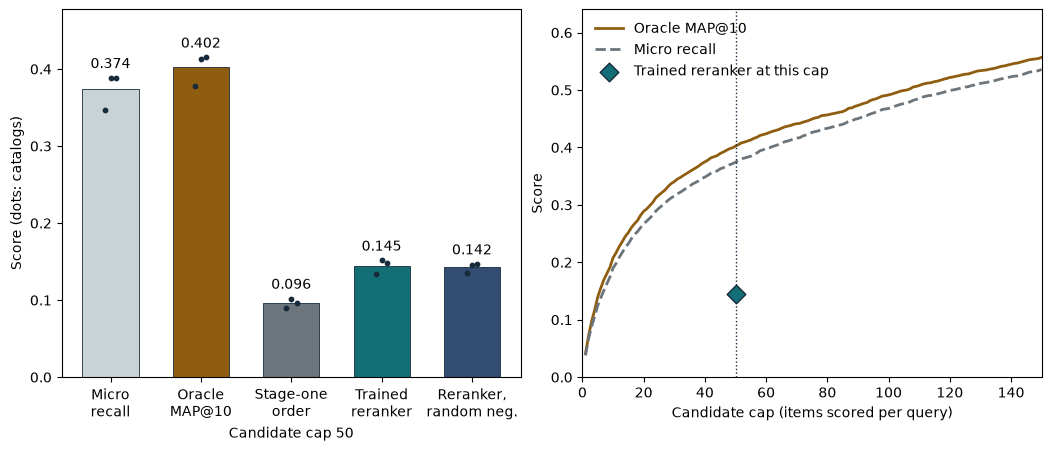

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch65 import draw, NCOLS, HEIGHT

DEFAULT = 50
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a cap of 50, stage one keeps 0.374 of all relevant items, the oracle MAP@10 is 0.402 and the trained reranker reaches 0.145: 0.402 - 0.145 = 0.257 of the ceiling is not captured. Keeping stage one's own order scores 0.096, so the reranker adds 0.049. A reranker trained on random negatives scores 0.142. Scoring 50 candidates per query costs 50,000 rows per 1,000 queries.

- Uncaptured ceiling: 0.402 - 0.145 = 0.257.
- Reranker gain over stage one's order: 0.145 - 0.096 = 0.049.
- Oracle against micro recall: 0.402 - 0.374 = 0.028.
- Random-negative reranker against the retrieved-candidate reranker: 0.142 - 0.145 = -0.003.

## Apply this to your competition

- Measure candidate recall and the metric-specific oracle for several caps before tuning the reranker.
- Train the reranker on the candidates your own stage one produces at the cap you will use, with the same cutoffs for validation queries.
- Choose the cap where the achieved score flattens, and price the rows scored: queries times candidates times models.
- Add or improve retrieval sources when the oracle is far above the achieved score; improve the reranker when the oracle is close.

Book location: Chapter 65, The Defining Shape: Retrieve, Then Rank.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)